In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [2]:
from bbhx.waveformbuild import BBHWaveformFD

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.


In [3]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13


In [4]:
merger_file="blackhole_mergers.hdf5"
merger_data=h5py.File(merger_file, 'r')
M_1=np.maximum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
M_2=np.minimum(merger_data['mass_out'],merger_data['mass_in'])*1e10/.6774
z=np.array(merger_data['time'])**(-1)-1

In [5]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value*1e6*PC_SI)

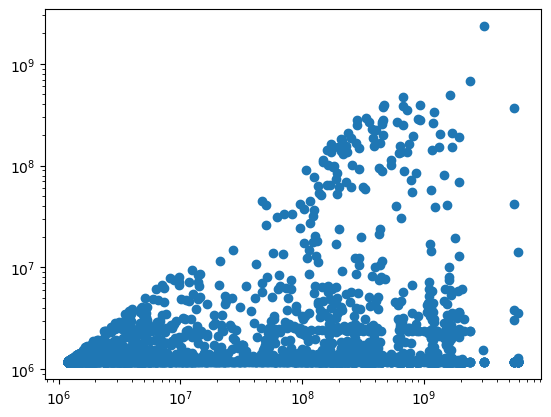

In [6]:
plt.loglog(M_1,M_2,'o')

In [7]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

In [8]:
#wave_gen = PhenomHMAmpPhase()

#parameters from simulation
#m1 = 2e6
#m2 = 7e5
#dist = 15 * 1e9 * PC_SI

#fixed parameters
#chi1 = 0.5
#chi2 = 0.7
#phi_ref = 0.6
#_ref = 0.0
#t_ref = 1e6 # seconds
#length = 1024

#wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)

In [9]:
# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer

In [10]:
m1 = M_1
m2 = M_2
dist = d_l
arr_size= len(m1)
chi1 = np.full(arr_size, 0.5)
chi2 = np.full(arr_size, 0.7)
phi_ref = np.full(arr_size, 0.6)
f_ref =  np.full(arr_size, 0.0)
inc =  np.full(arr_size, np.pi / 8)
lam =  np.full(arr_size, 0.5)
beta = np.full(arr_size, -0.7)
psi = np.full(arr_size, np.pi/4)
t_ref = np.full(arr_size, 1e6) # seconds

length = 1024

# setup data holders
Tobs = YRSID_SI/12   # 1 month
dt = 10.0  # sec
N = int(Tobs / dt)
Tobs = N * dt

freqs = np.fft.rfftfreq(N, dt)

#print(freqs) """ 

In [11]:
tdi_wave_gen = BBHWaveformFD()

In [12]:
""" wave_AET=[]
for i in range(700):
    AET_gen = tdi_wave_gen(
        m1[i],
        m2[i], 
        chi1[i],
        chi2[i],
        dist[i], 
        phi_ref[i],
        f_ref[i], 
        inc[i],
        lam[i],
        beta[i],
        psi[i],
        t_ref[i],
        length=1024, 
        combine=False,  # TODO: check this
        direct=False,
        fill=True,
        squeeze=True,
        freqs=freqs
    )[0]
    wave_AET.append(AET_gen)
    #print(AET_gen)

    #print(AET.shape)
wave_AET=np.array(wave_AET)
#print(wave_AET.shape) """

' wave_AET=[]\nfor i in range(700):\n    AET_gen = tdi_wave_gen(\n        m1[i],\n        m2[i], \n        chi1[i],\n        chi2[i],\n        dist[i], \n        phi_ref[i],\n        f_ref[i], \n        inc[i],\n        lam[i],\n        beta[i],\n        psi[i],\n        t_ref[i],\n        length=1024, \n        combine=False,  # TODO: check this\n        direct=False,\n        fill=True,\n        squeeze=True,\n        freqs=freqs\n    )[0]\n    wave_AET.append(AET_gen)\n    #print(AET_gen)\n\n    #print(AET.shape)\nwave_AET=np.array(wave_AET)\n#print(wave_AET.shape) '

In [13]:
#print(wave_AET.shape)

In [36]:
arr_size = len(M_1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc(m1 = M_1, m2 = M_2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 1e6),
             num_elements = len(M_1)):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12   # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )[0]
        
        data = DataResidualArray(AET_gen, f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr)
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new


/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:83: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:85: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:87: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:92: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/fotik17/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/sensitivity.py:94: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi *

In [ ]:
# Calling the function
#snr_tng50 = SNR_calc()

In [37]:
#print(snr_tng50)

[1263.0277094728322, 1522.8576338433827, 1957.1762587484666, 2083.272136871314, 2198.5532932804877, 2103.986543258333, 2113.3526447935938, 2048.2502049701734, 2165.158355689647, 2149.126051159065, 2223.50887701236, 2273.4961602829403, 2229.3131713694374, 2473.479420095315, 2350.2300210265753, 2387.975597147582, 3129.2251793567607, 2548.418826356816, 2469.7930508043914, 2550.197035140379, 2512.622580976347, 2505.0934080086954, 2802.438274597072, 3079.1722396251416, 3041.6776231893346, 3037.021097663421, 2480.5778884378415, 2980.3236756269653, 2386.015733506638, 3170.124460983924, 2729.638241117563, 2665.135944746803, 2695.145291871026, 3150.693383356347, 2617.8628689178367, 2783.744799478217, 3280.5899129435693, 2907.785744395092, 3367.016450684049, 1906.3584025883295, 3081.8847958829733, 2886.2717511472697, 2976.250266233286, 1617.368639505984, 2979.4339670719287, 2994.8826520370767, 29.798919921124494, 3021.2617899726356, 2908.267773413116, 3564.99117093925, 2054.064436825247, 2764.15

In [14]:
""" with h5py.File('wave_AET.h5', 'w') as hdf_file:
    hdf_file.create_dataset('wave_AET', data=wave_AET) """

In [16]:
fn = np.logspace(-6, -1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")
plt.loglog(fn, Sn_char_strain)
plt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label='A')
plt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label='E')
plt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label='T')
plt.legend()

' fn = np.logspace(-6, -1, 10000)\nSn_char_strain = get_sensitivity(fn, sens_fn="A1TDISens", return_type="char_strain")\nplt.loglog(fn, Sn_char_strain)\nplt.loglog(freqs, freqs * np.abs(wave_AET[0,1]),label=\'A\')\nplt.loglog(freqs, freqs * np.abs(wave_AET[1,1]),label=\'E\')\nplt.loglog(freqs, freqs * np.abs(wave_AET[2,1]), label=\'T\')\nplt.legend() '

In [18]:
#wave_AET= np.load('wave_AET.npy')


In [17]:
""" snr_tng50=[]
for i in range(700):
    data = DataResidualArray(wave_AET[i], f_arr=freqs)
    sens_mat = AET1SensitivityMatrix(data.f_arr)
    analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
    snr=analysis.snr()
    snr_tng50.append(snr)
    #print(snr_tng50)
 """

In [39]:
#snr_tng50=analysis.snr()
#np.save('snr_tng50.npy', snr_tng50)

In [5]:
snr_tng50=np.load('snr_tng50.npy')

Text(0, 0.5, 'SNR')

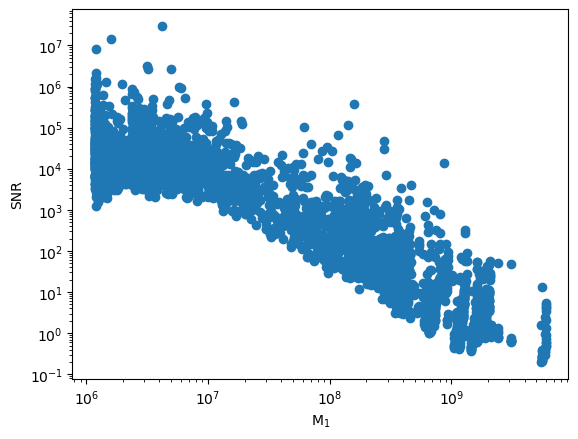

In [38]:
plt.loglog(M_1,snr_tng50,'o')
plt.xlabel('M$_1$')
plt.ylabel('SNR')